# Exploratory Data Analysis of Amazon Reviews
## Introduction

#### Why do an exploratory data analysis?
- In short, **to understand the structure and contents of the data** we're working with, and **ensure its quality**.
- If we understand the data, we can decide if it suits our purposes, and choose appropriate models to process it.
- It also helps to reduce the risk of invalid results, and handle deficiencies (e.g., missing or inconsistent values, exposed bias, etc.) early on.
- Exposing surface-level patterns can help us formulate assumptions for our upcoming experiments.


#### Dataset used in this notebook:
Source: https://www.kaggle.com/datasets/mexwell/amazon-reviews-multi <br>
Released under Amazon.com Conditions of Use with an academic research license. <br>
License Information: https://docs.opendata.aws/amazon-reviews-ml/readme.html

## 1. Install and import libraries

#### Install libraries
uncomment and run to install

In [2]:
#!pip install pandas
#!pip install matplotlib
#!pip install ollama
#!pip install pydantic
#!pip install tiktoken

#### Import the installed libraries

In [1]:
# For the pandas-based analysis:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

# For keyword extraction with LLMs (AI-based keyword extraction)
from ollama import chat
from pydantic import BaseModel
from collections import Counter
import json
import tiktoken

_______________________

## 2. Load and prepare the data for exploration
#### Load the data files
make sure the .csv files are in the same directory as your notebook;

otherwise, change the path to the file in the ```read_csv()``` function argument

In [2]:
train_df = pd.read_csv('train.csv')
validation_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

#### Check the basic stats and infos
- number of instances
- data types
- data fields (i.e. the number and names of columns)
- missing values

In [5]:
print(f"Number of training instances: {train_df.shape[0]:,}")                                 # 1,200,000
print(f"Number of validation instances: {validation_df.shape[0]:,}")                          # 30,000
print(f"Number of test instances: {test_df.shape[0]:,}")                                      # 30,000
print(f"Total instances: {train_df.shape[0] + validation_df.shape[0] + test_df.shape[0]:,}")  # 1,260,000

Number of training instances: 1,200,000
Number of validation instances: 30,000
Number of test instances: 30,000
Total instances: 1,260,000


In [6]:
# We get to see the column names, data types and which columns miss any values:
print(train_df.info())
print(validation_df.info())
print(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   Unnamed: 0        1200000 non-null  int64
 1   review_id         1200000 non-null  str  
 2   product_id        1200000 non-null  str  
 3   reviewer_id       1200000 non-null  str  
 4   stars             1200000 non-null  int64
 5   review_body       1200000 non-null  str  
 6   review_title      1199957 non-null  str  
 7   language          1200000 non-null  str  
 8   product_category  1200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 82.4 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        30000 non-null  int64
 1   review_id         30000 non-null  str  
 2   product_id        30000 non-null  str  
 3   rev

#### What we've learned about the dataset structure?
- every review comes with a review id, a product id, a reviewer id, a star rating, review body and title, language and a product category
- each review is linked to a product, however no product name is available, but only a product category
- the reviews are available in several languages
- all languages combined, we get over a million review instances
- ratings are stored as integers, the rest as strings
- apart from a few review titles, no values are missing

In [9]:
# take look at a short data sample
train_df.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy


#### Concatenate the train, validation and train splits
We don't require the dataset to be split for the purpose of data exploration. We want to gain insights into *all* data.

In [3]:
concatenated_df = pd.concat([train_df, validation_df, test_df])
instances_count = concatenated_df.shape[0]
print(f"Total concatenated instances (check): {instances_count:,}")

Total concatenated instances (check): 1,260,000


____________________________

## 3. Closer look at products, product categories and ratings
What information can we work with?
- We can look at the product distribution
- We can check the rating distribution
- We can explore how many reviews are available per language
- We can look at the dataset across all languages, as well as splits by language, product category, a star rating, or various combinations of them

First, let's look at the data set as a whole, and after that explore the individual splits.
#### How much of the same product do we get in this dataset? (all languages)
As seen in section 2, the product names are not available in this dataset; However, each review is linked to a product with a unique product id.

In [14]:
unique_product_ids = len(concatenated_df['product_id'].unique())
unique_product_proportion = unique_product_ids / instances_count * 100
print(f"Number of unique product IDs (out of 1,260,000 products): {unique_product_ids:,}")
print(f"Percentage of unique products in the dataset: {unique_product_proportion:.2f}%")
# -> the majority of reviews (~80%) are linked to exactly one product

Number of unique product IDs (out of 1,260,000 products): 1,001,790
Percentage of unique products in the dataset: 79.51%


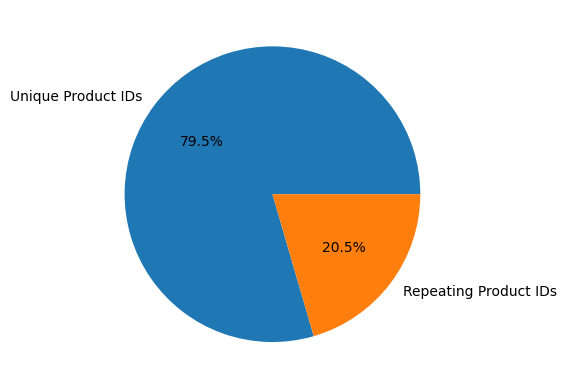

In [21]:
unique_products_plot = np.array([unique_product_proportion, 100-unique_product_proportion])
unique_product_labels = [f"Unique Product IDs", f"Repeating Product IDs"]

plt.pie(unique_products_plot, labels = unique_product_labels, autopct='%1.1f%%')
plt.show()

#### Product category distribution (all languages)

In [32]:
prod_categories_counts = concatenated_df["product_category"].value_counts()
print(f"Total number of product categories: {len(prod_categories_counts)}")
print("______________________________")
print(f"Reviews distribution across product categories: {prod_categories_counts}")

Total number of product categories: 31
______________________________
Reviews distribution across product categories: product_category
home                        132377
wireless                    115958
book                         95290
sports                       68683
apparel                      60468
toy                          59859
pc                           58410
home_improvement             56166
beauty                       55328
kitchen                      53932
drugstore                    50171
electronics                  47110
other                        44271
automotive                   43579
digital_ebook_purchase       35987
shoes                        34056
office_product               27788
pet_products                 27613
baby_product                 26342
lawn_and_garden              25729
grocery                      24924
furniture                    20921
camera                       15665
luggage                      14519
jewelry                  

- most reviews concern products from categories "home", "wireless" and "book"
- product distribution is unbalanced, which may result in a bias for some applications (e.g., a model that learns from this dataset might favour the vocabulary and sentiment it has learned from the ```home```  product category, since it is the prevailing one)

<Axes: ylabel='product_category'>

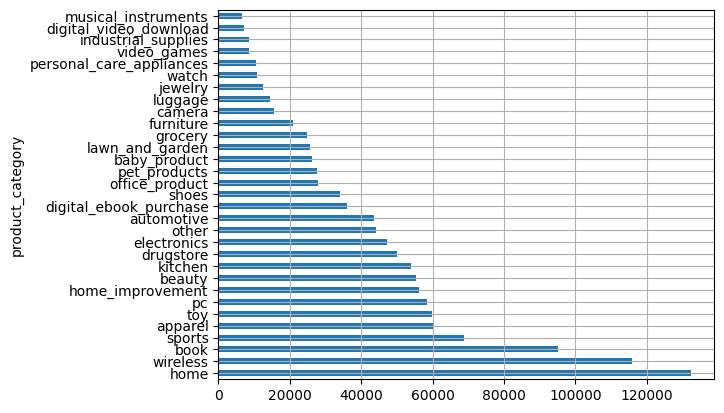

In [65]:
# visualise the product category distribution as a horizontal bar plot
prod_categories_counts.plot.barh(grid=True)

#### Rating distribution (all languages)

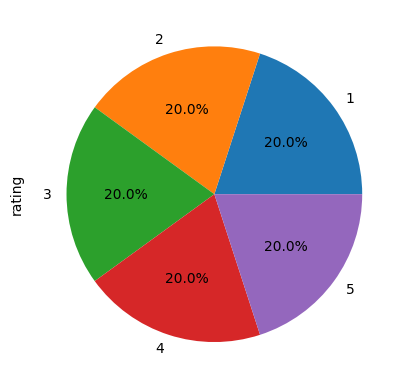

In [29]:
ratings_counts = concatenated_df["stars"].value_counts().plot.pie(autopct='%1.1f%%', ylabel="star rating")

- the dataset is balanced in terms of the star rating distribution

#### Rating distribution within product categories (all languages)

In [78]:
# going through each product category individually, we want to inspect the ratings distributions
def ratings_in_prod_category(df, category):
    filtered_prod_category = df[df["product_category"] == category]
    return filtered_prod_category["stars"].value_counts()

In [79]:
# get the product category names in a list:
prod_categories_names = concatenated_df["product_category"].unique()
print(prod_categories_names)

<StringArray>
[                  'sports',         'home_improvement',
                'drugstore',                      'toy',
             'baby_product',          'lawn_and_garden',
              'electronics',                     'book',
                     'home',                 'wireless',
                       'pc',                    'shoes',
               'automotive',                'furniture',
                   'beauty',   'digital_ebook_purchase',
                  'kitchen', 'personal_care_appliances',
           'office_product',                  'apparel',
              'video_games',             'pet_products',
   'digital_video_download',      'musical_instruments',
                    'other',                    'watch',
                  'luggage',                  'jewelry',
                   'camera',      'industrial_supplies',
                  'grocery']
Length: 31, dtype: str


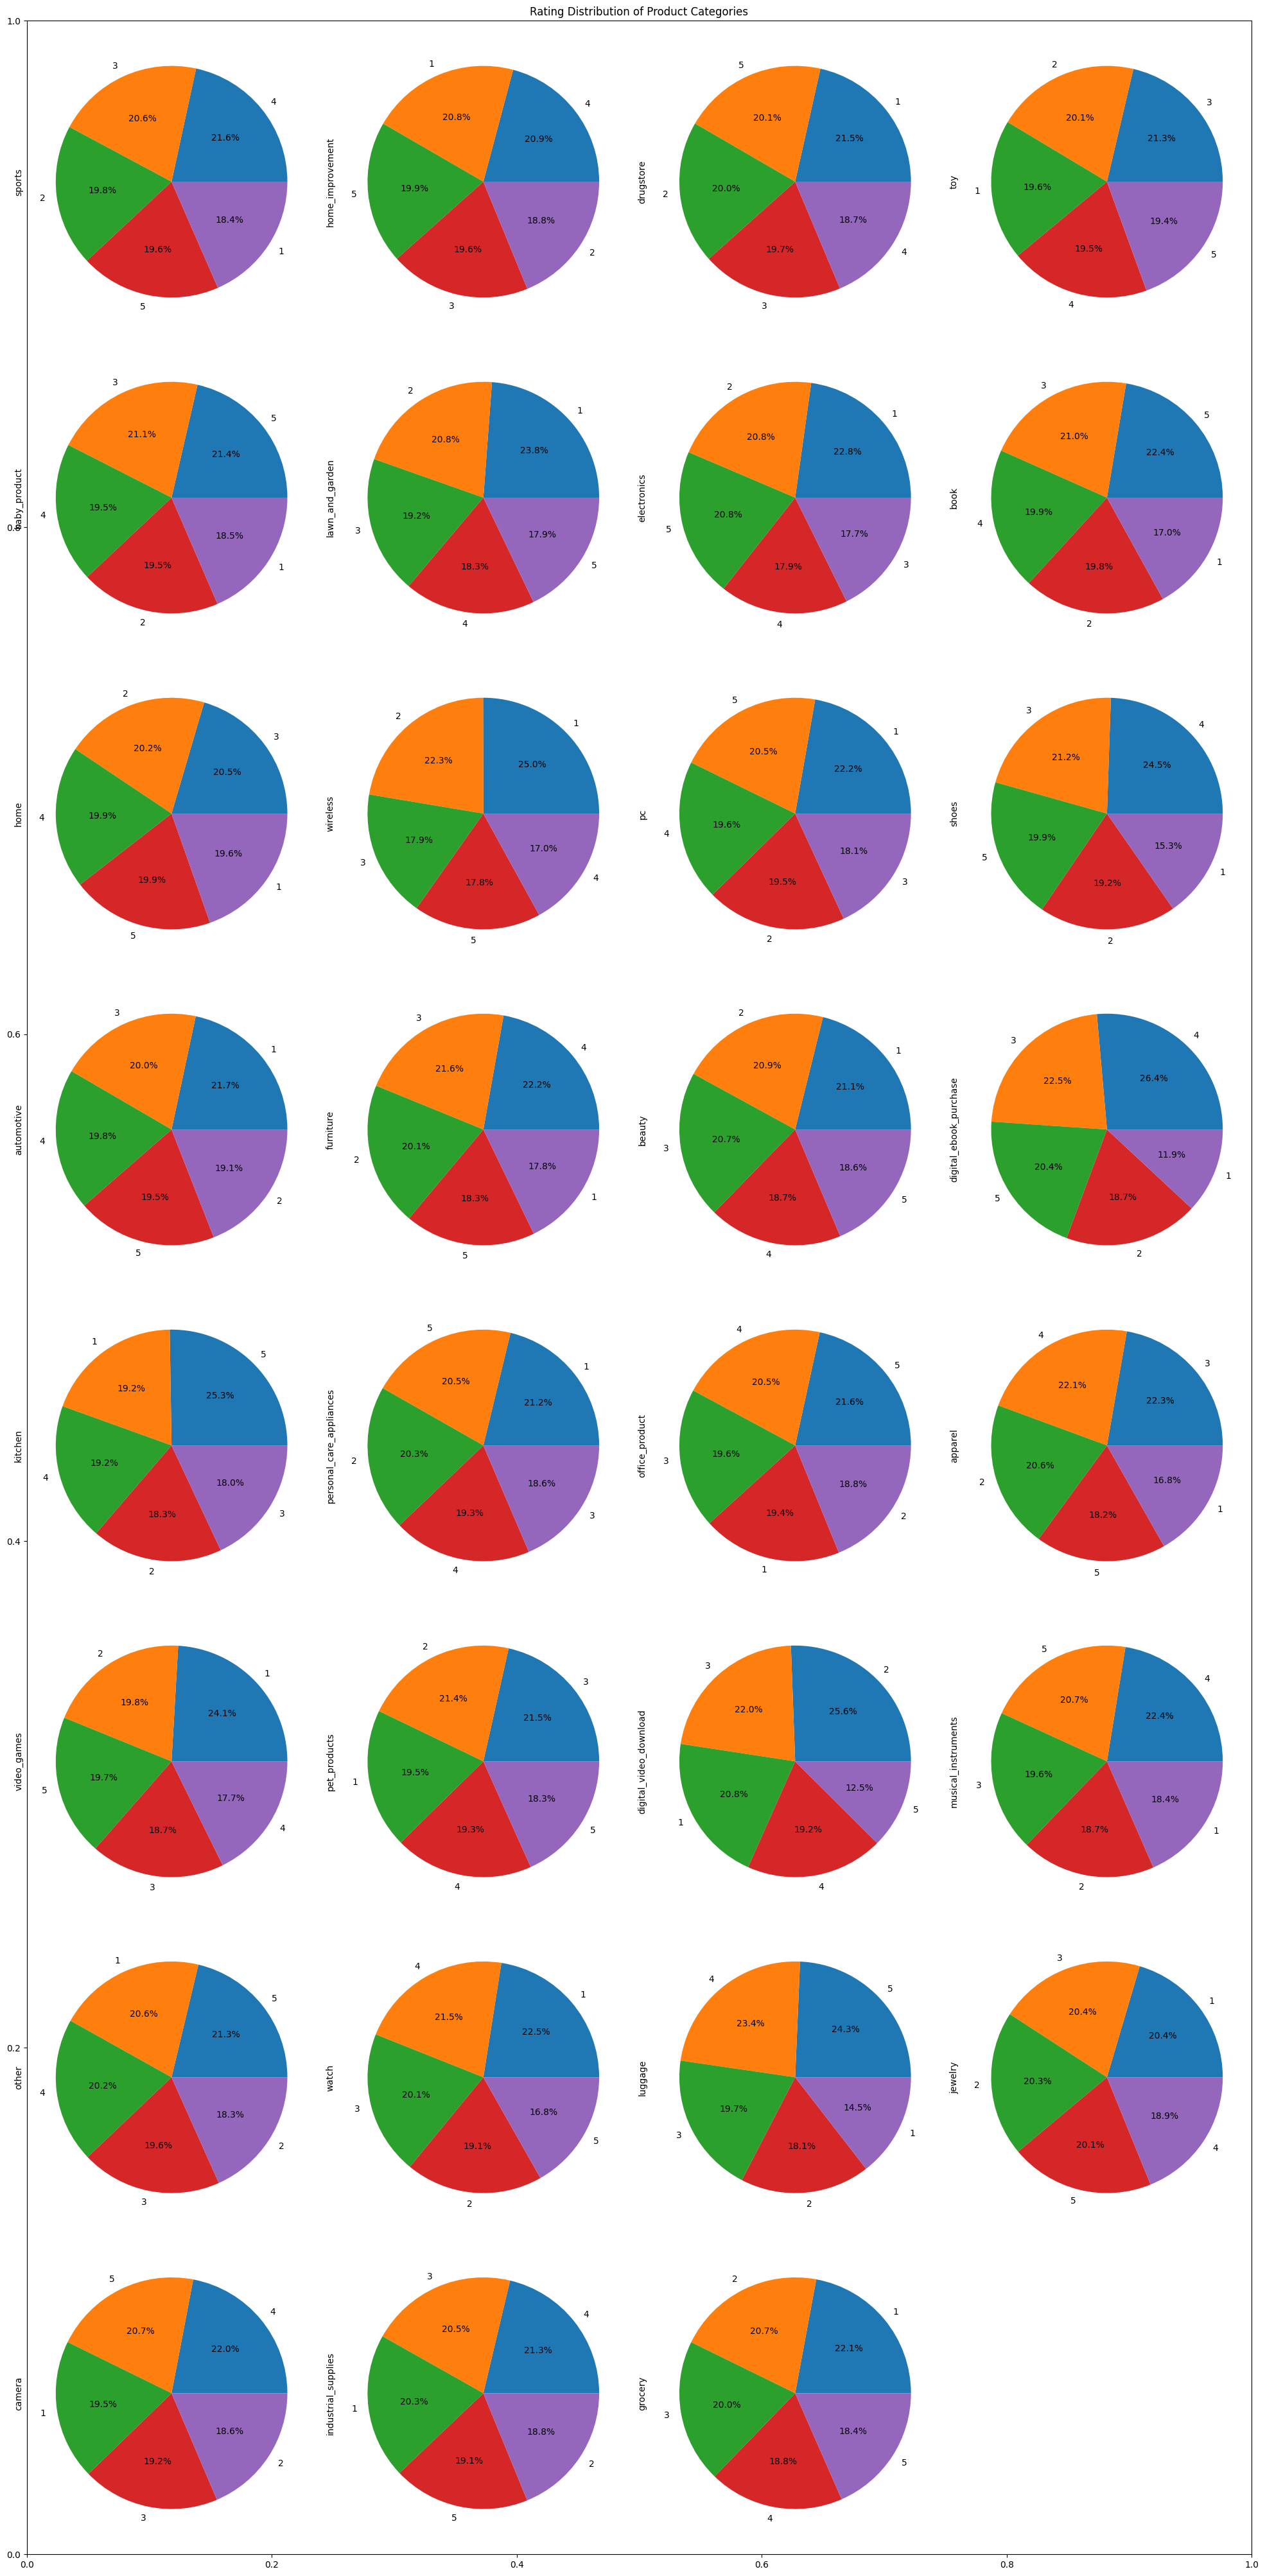

In [87]:
# plot the rating distributions per product category
plt.figure(figsize=(20, 40))
plt.title("Rating Distribution of Product Categories")

for plot_number, prod_cat in enumerate(prod_categories_names):
    plt.subplot(8, 4, plot_number + 1)
    ratings_in_prod_category(concatenated_df, prod_cat).plot.pie(autopct='%1.1f%%', ylabel=prod_cat)
    plt.tight_layout()

- we see that ratings are rather balanced across all product categories across all languages, too
- we would probably not expect any positive/negative bias if we use all languages for model training

## 4. Comparisons across markets
- assumption: one language = one market <br>
The assumption is supported by the reference research paper by Keung at al. (https://aclanthology.org/2020.emnlp-main.369/) - they filtered out all reviews where the language did not align with the target market.

In [33]:
markets_counts = concatenated_df["language"].value_counts()
print(f"Total number of markets: {len(markets_counts)}")
print("_______________________________")
print(f"Available languages: {markets_counts}")

Total number of markets: 6
_______________________________
Available languages: language
de    210000
en    210000
es    210000
fr    210000
ja    210000
zh    210000
Name: count, dtype: int64


Available markets/languages are (verified with the research paper):
- Germany (de)
- USA (en)
- Spain (es)
- France (fr)
- Japan (ja)
- China (zh)

- The instances are balanced across languages: there are 210,000 reviews per each language

#### Product category distributions in different markets

In [7]:
# get the list of languages from the data frame
languages = concatenated_df["language"].unique()
print(languages)

<StringArray>
['de', 'en', 'es', 'fr', 'ja', 'zh']
Length: 6, dtype: str


In [8]:
# we will need to filter reviews belonging to one language,
# and then get the desired distribution (e.g. ratings or product category) for each language, i.e. market
def get_distribution(df, language: str, category: str):
    return df[df["language"]==language][category].value_counts()

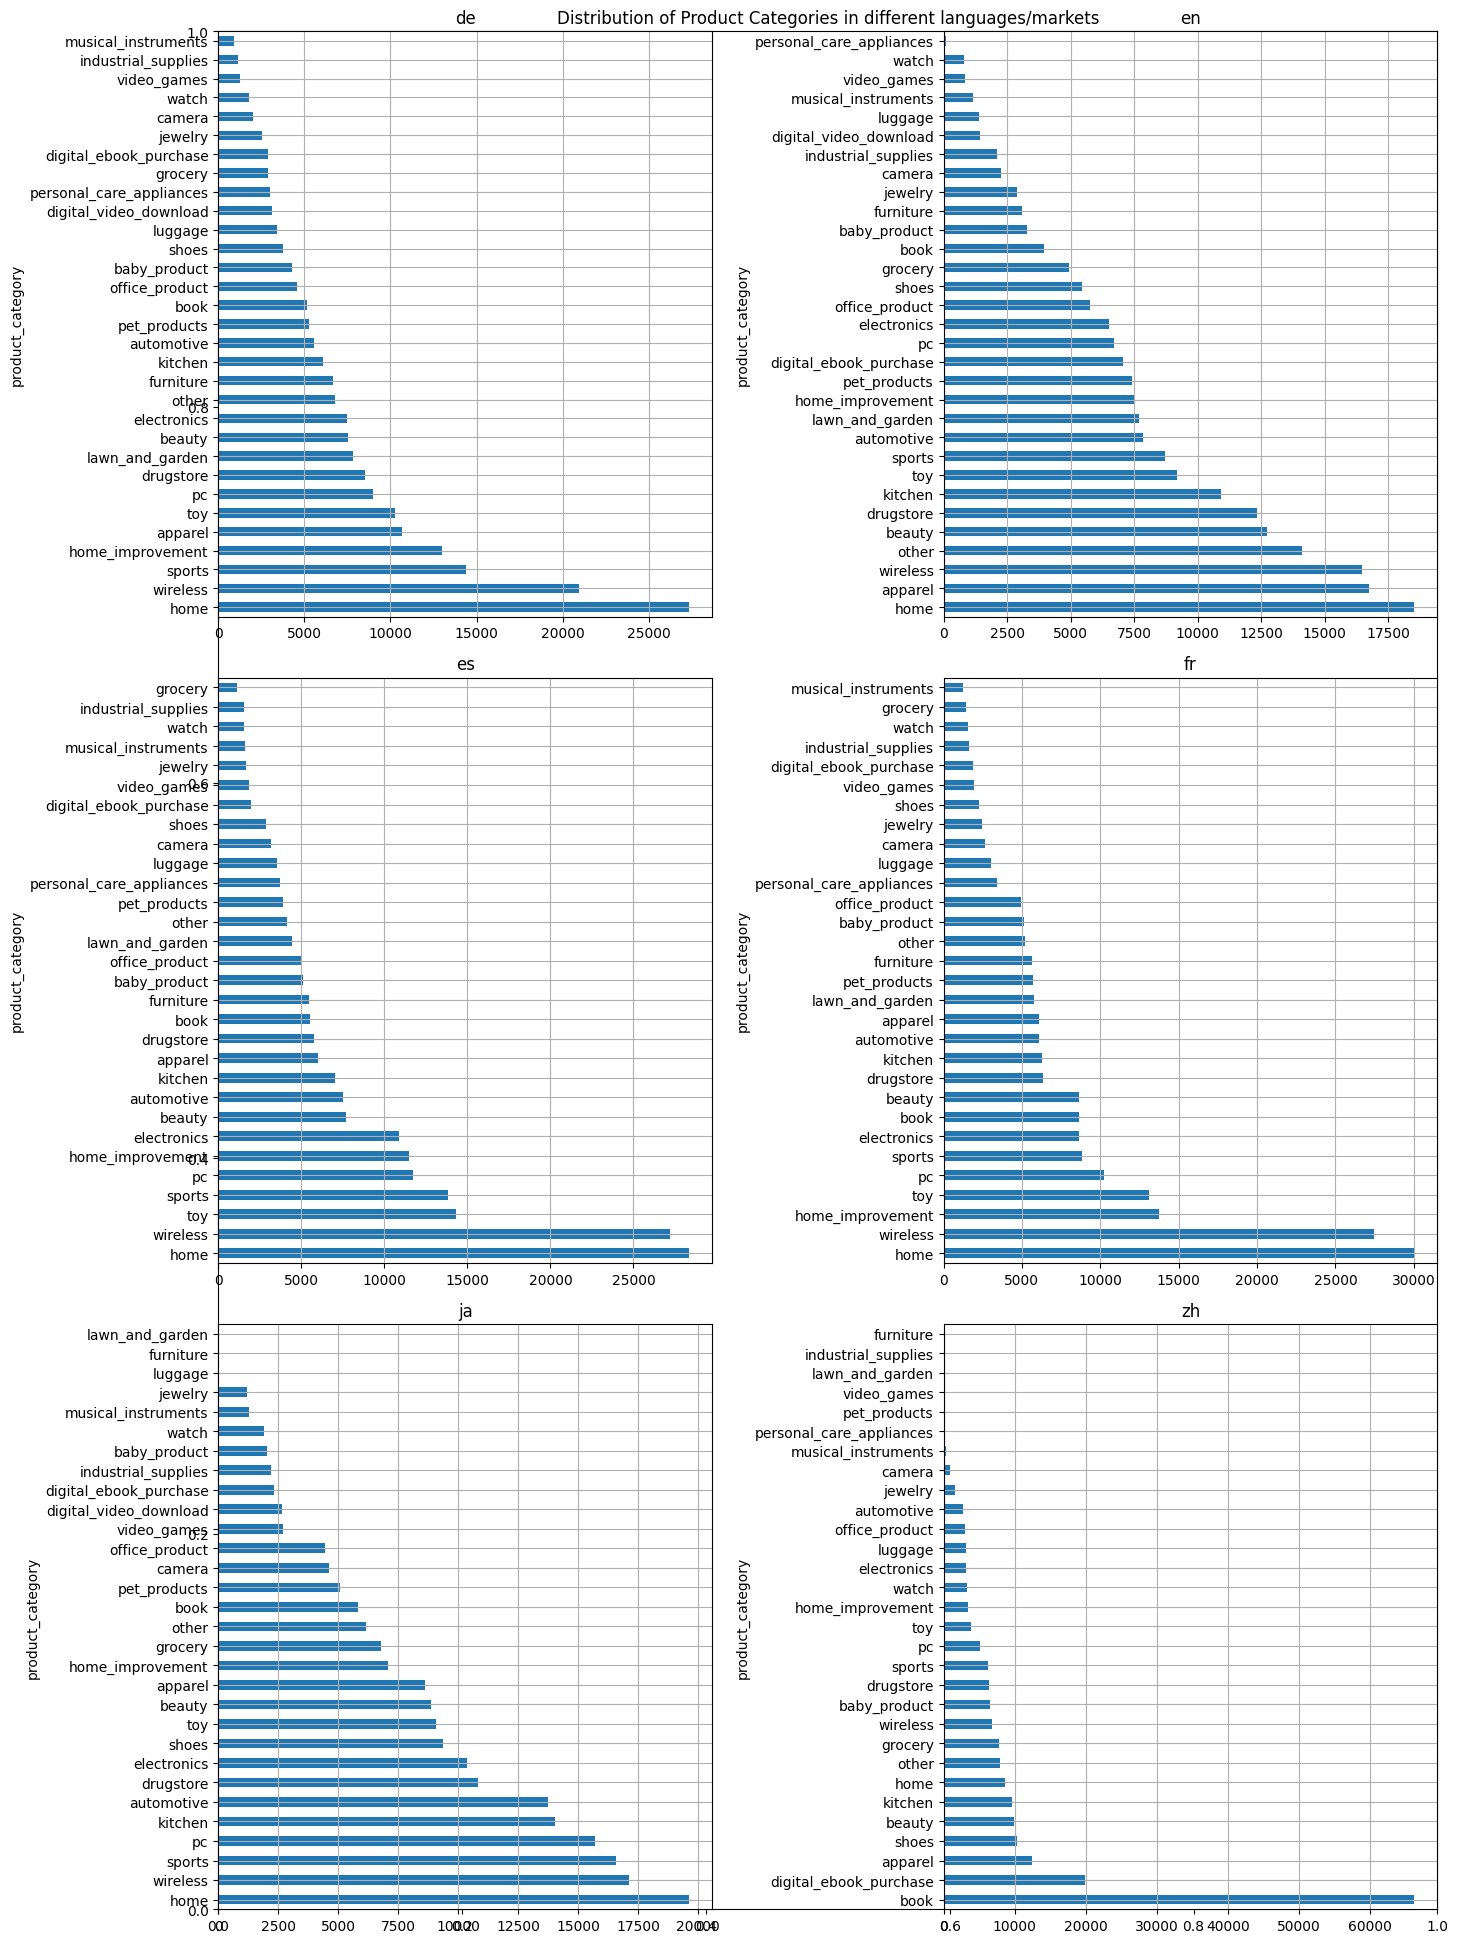

In [9]:
plt.figure(figsize=(15, 20))
plt.title("Distribution of Product Categories in different languages/markets")

for plot_number, language in enumerate(languages):
    plt.subplot(3, 2, plot_number + 1)
    get_distribution(concatenated_df, language, "product_category").plot.barh(grid=True)
    plt.title(language)
    plt.tight_layout()

- ```home``` and ```wireless``` categories are consistently in the top 3 of all languages, except for Chinese;
- reviews in the Chinese language are predominantly about books (and e-books)

In [10]:
# a function that helps understand the language proportions of reviews within a certain product category
def language_source_within_prod_category(df, prod_category: str):
    """
    :param df: source dataframe
    :param prod_category: the product category of interest
    :return: the plot of language distribution for the product category
    """
    # filter the product category of interest
    filtered_prod_category_df = df[df["product_category"]==prod_category]
    title = f"language distribution for reviews in the --{prod_category}-- category"
    filtered_prod_category_df["language"].value_counts().plot.pie(autopct='%1.1f%%', title=title)

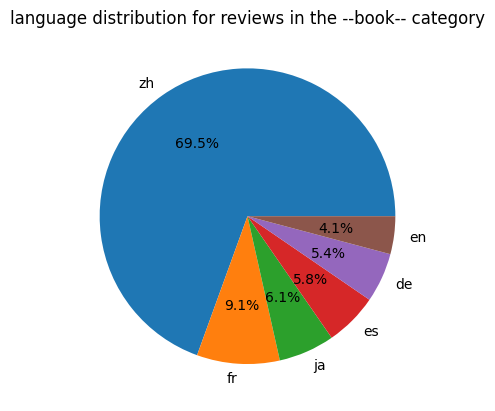

In [11]:
# e.g., it helps to visualize that the majority of book reviews are coming from the Chinese market
language_source_within_prod_category(concatenated_df, "book")

- Potentially, this language imbalance might become a source of bias, if we're training the model with data from all languages

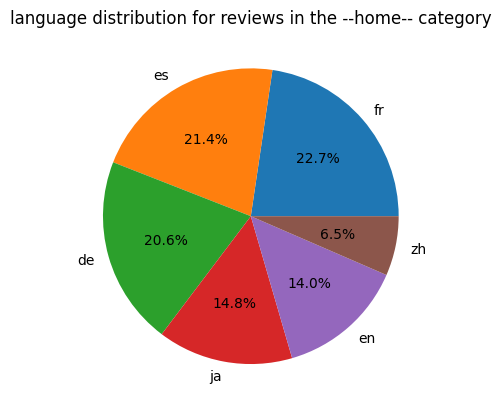

In [12]:
# e.g., the language/market distribution of the largest product category (home) is more evenly distributed, though
# ironically, with the exception of Chinese-language reviews
language_source_within_prod_category(concatenated_df, "home")

#### Rating distributions in different markets

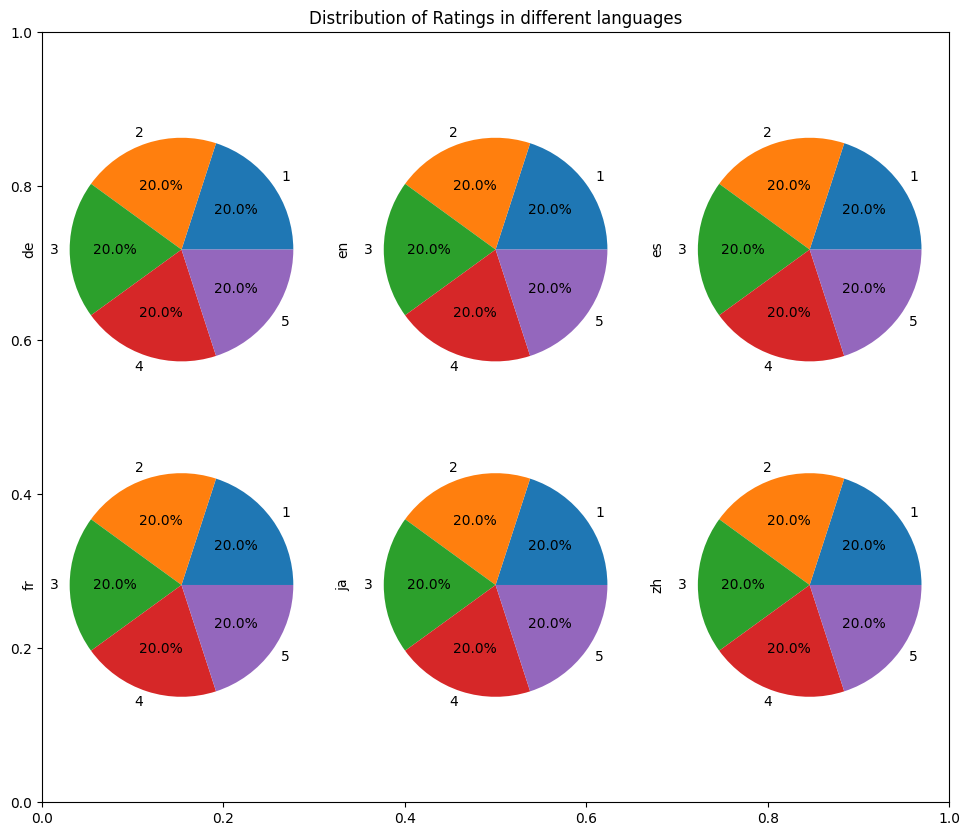

In [90]:
plt.figure(figsize=(10, 8))
plt.title("Distribution of Ratings in different languages")

for plot_number, language in enumerate(languages):
    plt.subplot(2, 3, plot_number + 1)
    get_distribution(concatenated_df, language, "stars").plot.pie(autopct='%1.1f%%', ylabel=language)
    plt.tight_layout()

- The ratings are evently distributed across all languages

#### Rating distributions in different languages/markets and in different product categories
We are going to track the rating distributions within product categories, similar to what we did in section 3, but this time we also add the language/market factor. We want to see if the rating distributions remain balanced from that perspective.

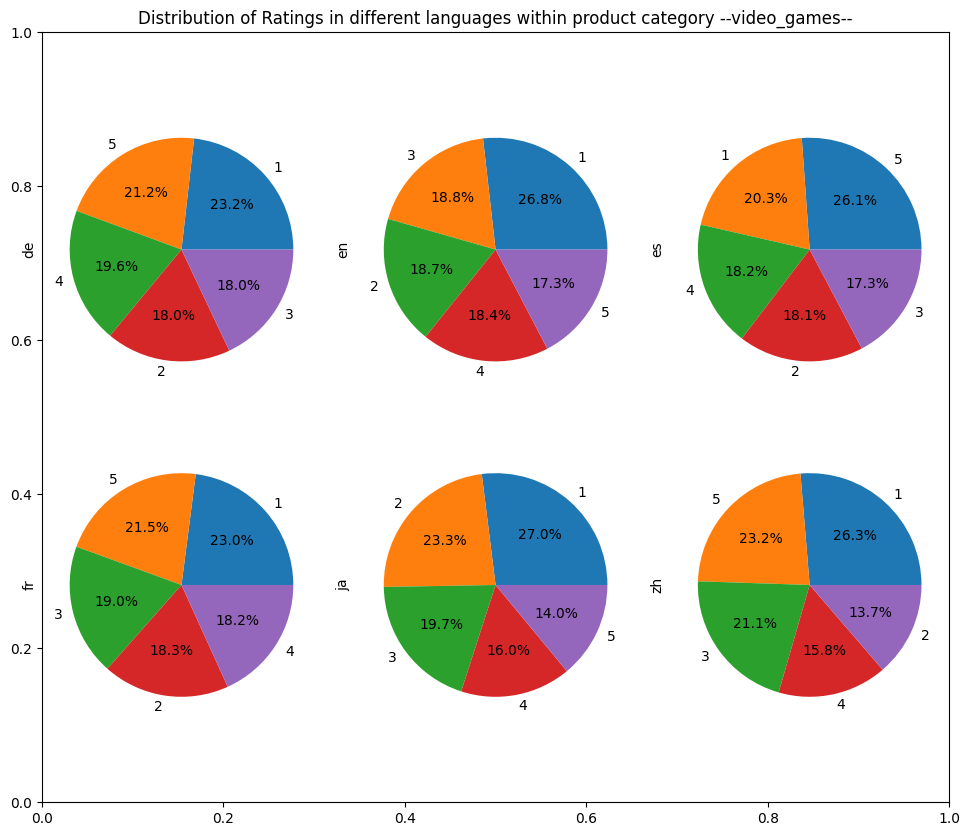

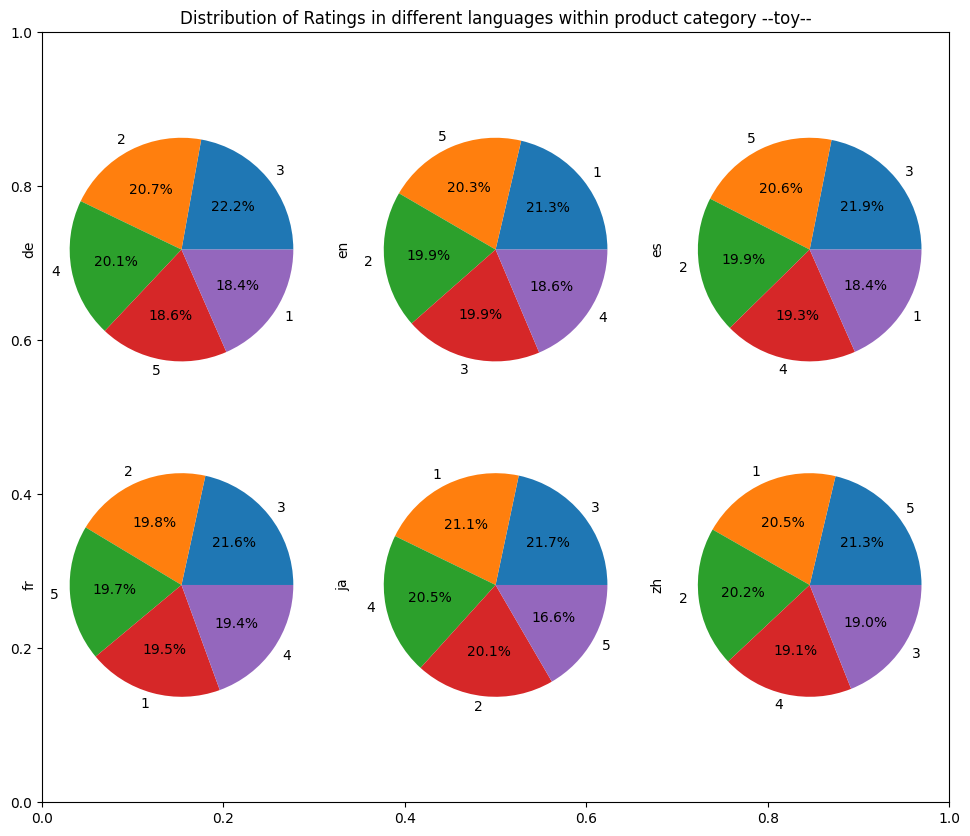

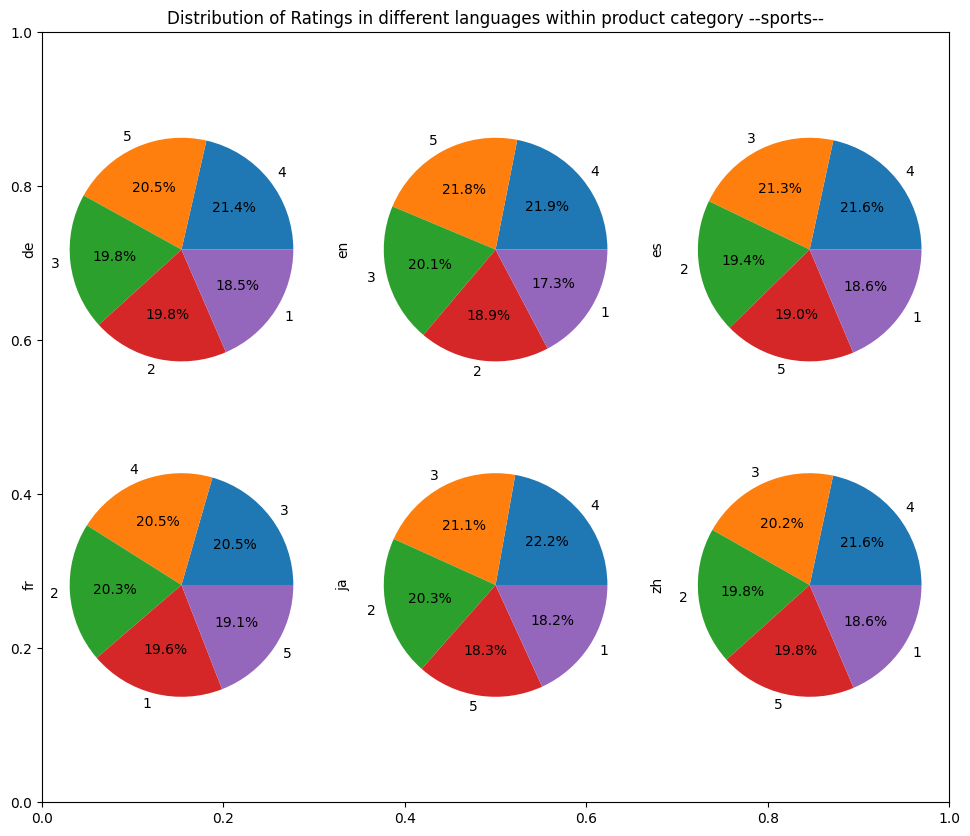

In [96]:
# Since the "languages x product categories" mapping would produce a lot of plots (6 languages x 31 categories), we will only sample a couple of random categories

# setting random seed for reproducibility
random.seed(42)

sample_prod_cats = random.sample(list(prod_categories_names), 3)
for prod_cat in sample_prod_cats:
    plt.figure(figsize=(10, 8))
    plt.title(f"Distribution of Ratings in different languages within product category --{prod_cat}--")
    # filter only the product category first
    filtered_prod_cat_df = concatenated_df[concatenated_df["product_category"]==prod_cat]

    for plot_number, language in enumerate(languages):
        plt.subplot(2, 3, plot_number + 1)
        get_distribution(filtered_prod_cat_df, language, "stars").plot.pie(autopct='%1.1f%%', ylabel=language)
        plt.tight_layout()

- We see that in the sampled product categories, the rating distributions remain predominantly balanced in all languages.
- This makes the dataset a good training material for rating-aware applications, e.g., senitment analysis
- The balance might be lost though, if the ratings are restructured, e.g., by combining reviews with ratings 1 and 2 into a "negative" sentiment polarity, and the rest in the "positive" polarity.

## 5. Keywords extraction
#### Why?
- to learn about the contents of the dataset
- to explore possibilities for user-centred applications, using this dataset

#### How do we extract the keywords?
- We are going to use an open-source LLM model (generative AI) with the help of **ollama** app - easy to install and run locally on own machine.
- For demonstration, we are going to work with the English subset of reviews belonging to the ```musical instruments``` product category; but the same can be done for any language, product category or combinations thereof.

- To avoid processing bottlenecks due to operating memory limitations of our local computer (see https://docs.ollama.com/context-length for details), we are going to chunk the reviews, and process chunks one by one.
- We will use one of ollama's smallest models, ```llama3.1:8b```, which should work on every computer.
- NOTE: if you don't want to run the keyword extraction model, you can use the saved keywords from the "keywords_musical_instruments_en.json" file. Scroll down and uncomment the dedicated line to do so.

#### Ollama setup:
- Install ollama: https://ollama.com/install.ps1
- Pull the LLM model:
    - in terminal: ```ollama pull llama3.1:8b```
    - or directly in notebook by uncommenting and running the line below:

In [ ]:
#!ollama pull "llama3.1:8b"

#### Prepare the subset of reviews to extract keywords from

In [4]:
# prepare the arguments for filtering: here we can choose the product category and the language
prod_category = "musical_instruments"   # -> can be changed here
language = "en"                         # -> can be changed here

In [5]:
# filter the review texts that are going to be used for the keyword extraction
texts_subset = concatenated_df["review_body"][(concatenated_df["language"] == language) & (concatenated_df["product_category"] == prod_category)].tolist()

In [29]:
# info about the subset we're working with
print(texts_subset[1]) # -> text of one review as sample
print("_________________________")
print(f"Number of English reviews in product category -{prod_category}-: {len(texts_subset):,}")
print("_________________________")
print(f"Number of tokens in the reviews: {len(' '.join(texts_subset)):,}")

I did not like the fact that it doesn't resemble the feel of a real guitar. I thought I was going to be to be able to practice playing on the go, but this was not the case. If you're looking for a practice tool to help you learn where to put your fingers I guess this would work. If you're looking for anything more than that this is not what you're looking for
_________________________
Number of English reviews in product category -musical_instruments-: 1,151
_________________________
Number of tokens in the reviews: 220,750


#### The keyword extraction pipeline:
1. Chunk the documents under consideration of context window (token) limitations of the model
2. Extract keywords per chunk
3. Aggregate chunk-keywords into one final overview

In [6]:
# LLM setup
LLM = "llama3.1:8b"         # -> model can be changed here
token_limit = 3000          # -> the chunk size can be changed here
max_keywords_per_chunk = 6  # -> the desired number of keywords per chunk can be changed here

random.seed(42)             # for reproducibility

In [8]:
def get_token_aware_chunks(texts: list[str], max_tokens_per_chunk: int) -> list[list[str]]:
    """Group reviews into chunks that fit within a token budget.
    Disclamer: This function was written by Claude Sonnet 4.6 under human supervision (mine),
    to help work with the tiktoken library.
    Single-hashtag comments are Claud's. Double-hashtag comments are mine.
    """
    # cl100k_base is a good approximation for Llama tokenizers
    enc = tiktoken.get_encoding("cl100k_base")
    chunks, current_chunk, current_tokens = [], [], 0
    for text in texts:
        token_count = len(enc.encode(text))
        ## fill the current chunk list up to the max token limit, update "chunks" and reset current chunk and tokens
        if current_tokens + token_count > max_tokens_per_chunk and current_chunk:
            chunks.append(current_chunk)
            current_chunk, current_tokens = [], 0
        current_chunk.append(text)
        current_tokens += token_count
    ## append the last chunk (rest of the texts)
    if current_chunk:
        chunks.append(current_chunk)
    return chunks

In [9]:
eng_chunks = get_token_aware_chunks(texts_subset, token_limit)
print(f"The resulting number of chunks is {len(eng_chunks)}")

The resulting number of chunks is 17


In [38]:
# sample of the first chunk
num_chunk = 1
# eng_chunks[num_chunk] # -> uncomment to see how the chunk looks like
print(f"Total reviews in Chunk {num_chunk}: {len(eng_chunks[num_chunk])}")

Total reviews in Chunk 1: 60


In [10]:
# precise instructions are important, but especially so with smaller models

def build_prompt(review_chunk, max_keywords):
    """ combine the reviews into one string, and formulate the prompt for the LLM """

    combined_reviews = "\n---\n".join(review_chunk)

    return f"""
    You are doing an exploratory analysis of Amazon reviews.
    Your task is to extract keywords from the text delimited by triple backticks.
    Rules:
    - Extract concrete product-related names, aspects and usage experiences.
    - Keywords can consist of 1-4 words.
    - Merge obvious synonyms into one normalized keyword.
    - Do not invent information not supported by the reviews.
    - Return exactly {max_keywords} keywords or fewer if the text does not support more.
    - Do not pad the list. If only one keyword is relevant, return that one keyword.
    - Only output the keywords, nothing else.
    ```{combined_reviews}```
    """

#### Note on the prompt formulation
Giving the LLM a few good examples in a prompt (called "few shots" in an NLP lingo) is usually considered a good practice in prompt engineering.
However, my pilot runs showed that adding examples to this prompt affects the results negatively, introducing bias towards the given examples. Initially, my prompt featured the following rule:
- *Examples of good keywords: "battery life", "pillow", "easy assembly"*

While these examples are valid in relation to Amazon reviews, they are not specific to the ```musical_instruments``` product category, that I run my tests with. As a result, my model "extracted" (but actually *hallucinated*) the keyword 'battery life' 15 times, 'pillow' 12 times and 'easy assembly' 12 times. <br>
I verified that these keywords are not even once present in the reviews subset of ```musical_instruments```. Apart from that, the occurrence frequences of these supposed keywords (15, 12, 12) are not consistent with other keywords found by the model, which usually remained in the 1-6 range. <br>
Thus, I excluded the keyword examples from the prompt; This might, however, work well for a different model, or a larger model for that matter. The general recommendation is to try out different prompt formulations and test them on various data subsets and scales.

In [11]:
# this is for ensuring the consistency of desired output format
class Keywords(BaseModel):
    keywords: list[str]

In [14]:
def extract_keywords(texts: list[list[str]], max_keywords: int) -> dict:
    len_texts = len(texts)
    all_keywords = []
    for i, text in enumerate(texts): # going through each chunk, extract at most <max_keywords> per chunk
        prompt = build_prompt(text, max_keywords)
        try:
            llm_response = chat(model=LLM,
                                messages=[{"role": "user", "content": prompt}],
                                format=Keywords.model_json_schema(),
                                options={"temperature": 0, # low temperature for stability of the output
                                         "num_gpu": 99}) #if your computer doesn't support GPU, take the "num_gpu" out
            parsed_response = Keywords.model_validate_json(llm_response["message"]["content"])
            all_keywords.extend(parsed_response.keywords[:max_keywords]) # add the keywords to the collection; cap if the llm overproduces keywords
        except Exception as e:
            print(f"Error: {e}, retrying...")

        # update the current process stats
        print(f"{i+1} out of {len_texts} chunks processed")
        print(f"Total number of keywords extracted: {len(all_keywords)}")
        print("____________________________________________")
    return Counter(all_keywords)

In [13]:
# test
test_chunk_1 = ["delivered on time, great bedside table", "delivery arrived late, the handle is broken"]
test_chunk_2 = ["good quality, but slow delivery"]
test_reviews = [test_chunk_1, test_chunk_2]
test_keywords = extract_keywords(test_reviews, 2)

print(test_keywords)

1 out of 2 chunks processed
Number of keywords extracted: 2
____________________________________________
2 out of 2 chunks processed
Number of keywords extracted: 4
____________________________________________
Counter({'bedside table': 1, 'handle': 1, 'quality': 1, 'delivery': 1})


In [15]:
# run the keyword extraction model
eng_keywords = extract_keywords(eng_chunks, max_keywords_per_chunk)

1 out of 17 chunks processed
Total number of keywords extracted: 6
____________________________________________
2 out of 17 chunks processed
Total number of keywords extracted: 12
____________________________________________
3 out of 17 chunks processed
Total number of keywords extracted: 18
____________________________________________
4 out of 17 chunks processed
Total number of keywords extracted: 24
____________________________________________
5 out of 17 chunks processed
Total number of keywords extracted: 30
____________________________________________
6 out of 17 chunks processed
Total number of keywords extracted: 36
____________________________________________
7 out of 17 chunks processed
Total number of keywords extracted: 42
____________________________________________
8 out of 17 chunks processed
Total number of keywords extracted: 48
____________________________________________
9 out of 17 chunks processed
Total number of keywords extracted: 54
_____________________________

In [112]:
# uncomment to save the keywords output for future use

#with open(f"keywords_{prod_category}_{language}.json", "w") as f:
#    json.dump(eng_keywords, f)

In [17]:
# uncomment to use previously generated keywords

#with open("keywords_musical_instruments_en.json", "r") as f:
#    eng_keywords = json.load(f)

In [18]:
# show the most common keywords across reviews (condition: come up more than once)
for kw, count in eng_keywords.items():
    if count > 1:
        print(f"{kw}: {count}")

guitar: 6
amp: 3
speakers: 2
microphone: 4
violin: 2
stand: 3
headphones: 2
quality: 2
sound: 2


In [19]:
# show a random selection keywords of frequency 1:
singletons = [kw for kw, count in eng_keywords.items() if count == 1]
selected_singletons = random.sample(singletons, 5)
print("Selected singletons:")
print("_____________")
for kw in selected_singletons:
    print(kw)

Selected singletons:
_____________
podcast
Behringer
Audio Technica
Joyo American Sound
Bluetooth


#### Experiment: Have the LLM infer the product category from the keywords

In [129]:
keyword_set = ", ".join([kw for kw in eng_keywords.keys()])
prompt_guess = f"""You are given a set of keywords delimeted by backticks. These are keywords extracted from Amazon reviews. Based on those keywords, guess the name of the product category. Only output the name of the product category, nothing else. Keywords: ```{eng_keywords}```"""

In [134]:
llm_guess = chat(model=LLM, messages=[{"role": "user", "content": prompt_guess}])

In [135]:
llm_guess["message"]["content"]

'Music Equipment'

##### Why is this a *good* usage of the keywords?
- The task is formulated in a way that LLM generates an output based only on the keywords it sees; there is not a lot of room for hallucination so the result is reliable.
- The result can be verified by comparing it to the original name of the product category: ```musical_instruments``` (output: *'Music Equipment'*)


#### Experiment: Have an LLM write a short summary about the reviews

In [145]:
prompt_summary = f"You are given a set of keywords delimeted by backticks. These are keywords extracted from Amazon reviews. Based on those keywords, write a short (between 20-50 words) summary about them. Mention a couple of product-related names, aspects and usage experiences. Only output the summary, nothing else. Keywords: ```{eng_keywords}```"

In [146]:
llm_summary = chat(model=LLM, messages=[{"role": "user", "content": prompt_summary}])

In [147]:
llm_summary["message"]["content"]
# Attention: the summary is good, but might not reflect the truth, as the context only includes the keywords and their frequencies, not sentiment polarities

'Amazon customers rave about musical instruments like guitars and violins, praising brands such as Fender and Vic Firth. However, some products receive criticism for poor quality, cheap materials, and false advertising. Others appreciate high-quality microphones from Rode and Audio Technica, while others enjoy Bluetooth earbuds and studio headphones for podcasting and karaoke sessions.'

##### Why is this a *bad* usage of the keywords?
- The generated summary uses the actual extracted keywords, and overall looks *plausible*.
- However, some of the claims made in the summary are not actually supported by the extracted keywords. For example, 'Rode', and 'Audio Technica' are indeed valid extracted keywords. But, they are extracted as *standalone* terms, in isolation of any sentiment or concrete product like microphone. Meaning, we don't know for sure if there are any reviews praising Rode microphones for their high quality. We can only be sure that the brand names 'Rode' and 'Audio Technica' comes up in the reviews.
- -> Therefore, the summary can be misleading. For it to work well, we might consider changing the format of the extracted keywords, e.g., by changing the extraction schema and asking the model to extract keywords together with positive or negative sentiment.

## 6. Results and conclusion
- We have carried out an exploratory analysis of Amazon reviews. We explored the dataset structure, visualised data splits in regards to product categories and languages, verified the quality of data, and gained an insight in some of its contents by extracting keywords.
- In the exploratory analysis, we used the programmatic data manipulation, descriptive statistics and visualisation techniques to explore the surface-level metadata, and generative AI models, including chunking and prompt engineering, for keyword extraction to gain a deeper understanding about the contents.
- We experimented with generative AI models to try out possible applications (guessing product categories and summary, both based on extracted keywords)
- We have seen that the dataset composition is balanced in regard to languages and ratings, thus making it a good training material, e.g., for sentiment analysis models and multilingual models. However, we note that re-structuring the dataset may result in ruining that balance (e.g., merging the 5 rating categories into 2 or 3 sentiment categories - positive, negative or neutral).
- We have also seen, that the balance is not really maintained within product categories. Some of them are represented with a considerably larger number of reviews (e.g., compare the reviews distribution between ```home``` and ```video_games``` product categories), which may result in the bias towards the vocabulary or sentiment stemming from the largest product categories.
- We have seen, that *even a small-sized, open-sourced AI model run locally*, can generate a fairly good set of keywords that can be used in further applications.